In [2]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#merging data

def read_csv_date(path,date_cols):
    """
        This function loads the file to read it and converts the dates colomns to dates
        """
    return pd.read_csv(path, parse_dates=date_cols, date_format='mixed')
# files dics to read and convert date colomns
file_config = {'deals':('olist_closed_deals_dataset.csv',['won_date']),
               'marketing':('olist_marketing_qualified_leads_dataset.csv',['first_contact_date']),
               'reviews':('olist_order_reviews_dataset.csv',['review_creation_date','review_answer_timestamp']),
               'orders':('olist_orders_dataset.csv',['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']),
               'orderitem':('olist_order_items_dataset.csv',['shipping_limit_date']),}


dfs = {name: read_csv_date(path,date_cols) for name, (path,date_cols) in file_config.items()}
# renaming colomns and merging the files
merged_emp_df = dfs['orderitem'].merge(dfs['orders'], on='order_id', how='left')
merged_emp_df2 = merged_emp_df.merge(dfs['reviews'], on='order_id', how='left')
merged_emp_df3 = dfs['marketing'].merge(dfs['deals'], on='mql_id')
df = merged_emp_df2.merge(merged_emp_df3, how='left', on='seller_id')
df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113310,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-03-28 18:50:57,computers,online_small,cat,NaN,NaN,NaN,reseller,NaN,0.0
113311,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113312,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,order_item_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,review_answer_timestamp,first_contact_date,won_date,declared_product_catalog_size,declared_monthly_revenue
count,113314.000000,113314,113314.000000,113314.000000,113314,113299,112111,110839,113314,112372.000000,112372,112372,5050,5050,0.0,5050.0
mean,1.198528,2018-01-07 06:41:43.931252992,120.478701,19.979428,2017-12-31 15:03:55.044654848,2018-01-01 02:39:54.835303168,2018-01-04 17:21:36.863795712,2018-01-14 04:20:16.402466560,2018-01-24 11:20:59.939636480,4.032473,2018-01-13 08:01:08.782258944,2018-01-16 11:18:34.300377600,2018-02-28 16:56:16.158415616,2018-03-22 19:55:47.444752640,NaN,0.0
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2016-10-06 00:00:00,2016-10-07 18:32:28,2017-07-14 00:00:00,2017-12-11 18:07:26,NaN,0.0
25%,1.000000,2017-09-20 12:31:27.750000128,39.900000,13.080000,2017-09-13 12:53:41.249999872,2017-09-13 21:58:38,2017-09-18 18:04:42,2017-09-26 17:35:15,2017-10-04 00:00:00,4.000000,2017-09-26 00:00:00,2017-09-28 09:44:15,2018-01-22 00:00:00,2018-02-08 17:29:13,NaN,0.0
50%,1.000000,2018-01-26 13:46:35,74.900000,16.260000,2018-01-19 14:34:32,2018-01-20 09:07:48,2018-01-24 15:46:47,2018-02-02 17:29:57,2018-02-15 00:00:00,5.000000,2018-02-02 00:00:00,2018-02-05 16:31:24,2018-02-28 00:00:00,2018-03-13 21:39:34,NaN,0.0
75%,1.000000,2018-05-10 11:15:14,134.900000,21.150000,2018-05-04 11:08:28,2018-05-04 17:22:10.500000,2018-05-08 11:18:00,2018-05-15 17:55:11,2018-05-25 00:00:00,5.000000,2018-05-16 00:00:00,2018-05-20 11:54:40.500000,2018-04-04 00:00:00,2018-04-24 03:00:00,NaN,0.0
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35,2018-05-31 00:00:00,2018-08-07 17:17:28,NaN,0.0
std,0.707016,NaN,183.279678,15.783227,NaN,NaN,NaN,NaN,NaN,1.387849,NaN,NaN,NaN,NaN,NaN,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113314 non-null  object        
 1   order_item_id                  113314 non-null  int64         
 2   product_id                     113314 non-null  object        
 3   seller_id                      113314 non-null  object        
 4   shipping_limit_date            113314 non-null  datetime64[ns]
 5   price                          113314 non-null  float64       
 6   freight_value                  113314 non-null  float64       
 7   customer_id                    113314 non-null  object        
 8   order_status                   113314 non-null  object        
 9   order_purchase_timestamp       113314 non-null  datetime64[ns]
 10  order_approved_at              113299 non-null  datetime64[ns]
 11  

In [6]:
# No duplicates
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
113309    False
113310    False
113311    False
113312    False
113313    False
Length: 113314, dtype: bool

In [7]:
df.shape

(113314, 36)

In [8]:
df.isnull().sum()

order_id                              0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1203
order_delivered_customer_date      2475
order_estimated_delivery_date         0
review_id                           942
review_score                        942
review_comment_title              99880
review_comment_message            65672
review_creation_date                942
review_answer_timestamp             942
mql_id                           108264
first_contact_date               108264
landing_page_id                  108264
origin                           108275
sdr_id                           108264


In [9]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'mql_id',
       'first_contact_date', 'landing_page_id', 'origin', 'sdr_id', 'sr_id',
       'won_date', 'business_segment', 'lead_type', 'lead_behaviour_profile',
       'has_company', 'has_gtin', 'average_stock', 'business_type',
       'declared_product_catalog_size', 'declared_monthly_revenue'],
      dtype='object')

In [10]:
df = df.drop(columns= ['has_company','has_gtin','average_stock','declared_monthly_revenue','declared_product_catalog_size','review_comment_title'])
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_id', 'review_score',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'mql_id', 'first_contact_date',
       'landing_page_id', 'origin', 'sdr_id', 'sr_id', 'won_date',
       'business_segment', 'lead_type', 'lead_behaviour_profile',
       'business_type'],
      dtype='object')

# Visualizations

In [47]:
def clean_chart(chart,labels=True,fmt='%.2f' , rota =0):
    ''' This function removes the borders, grid, and y-axis of the charts and labels the colomns on the top
     '''
    if labels:
        for container in chart.containers:
            chart.bar_label(container, fmt=fmt, padding = 3, rotation = rota)
    chart.get_yaxis().set_visible(False)
    chart.grid(False)
    chart.spines[['left','right','top']].set_visible(False)
    chart.margins(y=0.12)
    title = chart.get_title().lower().replace(' ', '_')
    chart.figure.savefig(f'{title}.png', transparent=True, dpi=300, bbox_inches='tight')
    return chart

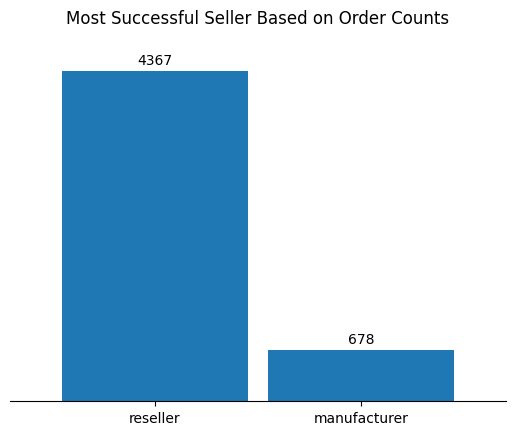

In [48]:
#Are resellers the most successful sellers?
#score_type= df.groupby('business_type')['review_score'].value_counts()
order_num_type= df.groupby('business_type')['order_id'].count().sort_values(ascending=False)
chart = order_num_type.plot(kind = 'bar', stacked=False, rot=0, width = 0.90, title='Most Successful Seller Based on Order Counts', xlabel = '');
#chart = plt.bar(x=order_num_type.index, height=order_num_type.values);
clean_chart(chart,labels=True,fmt='%.0f' , rota =0);

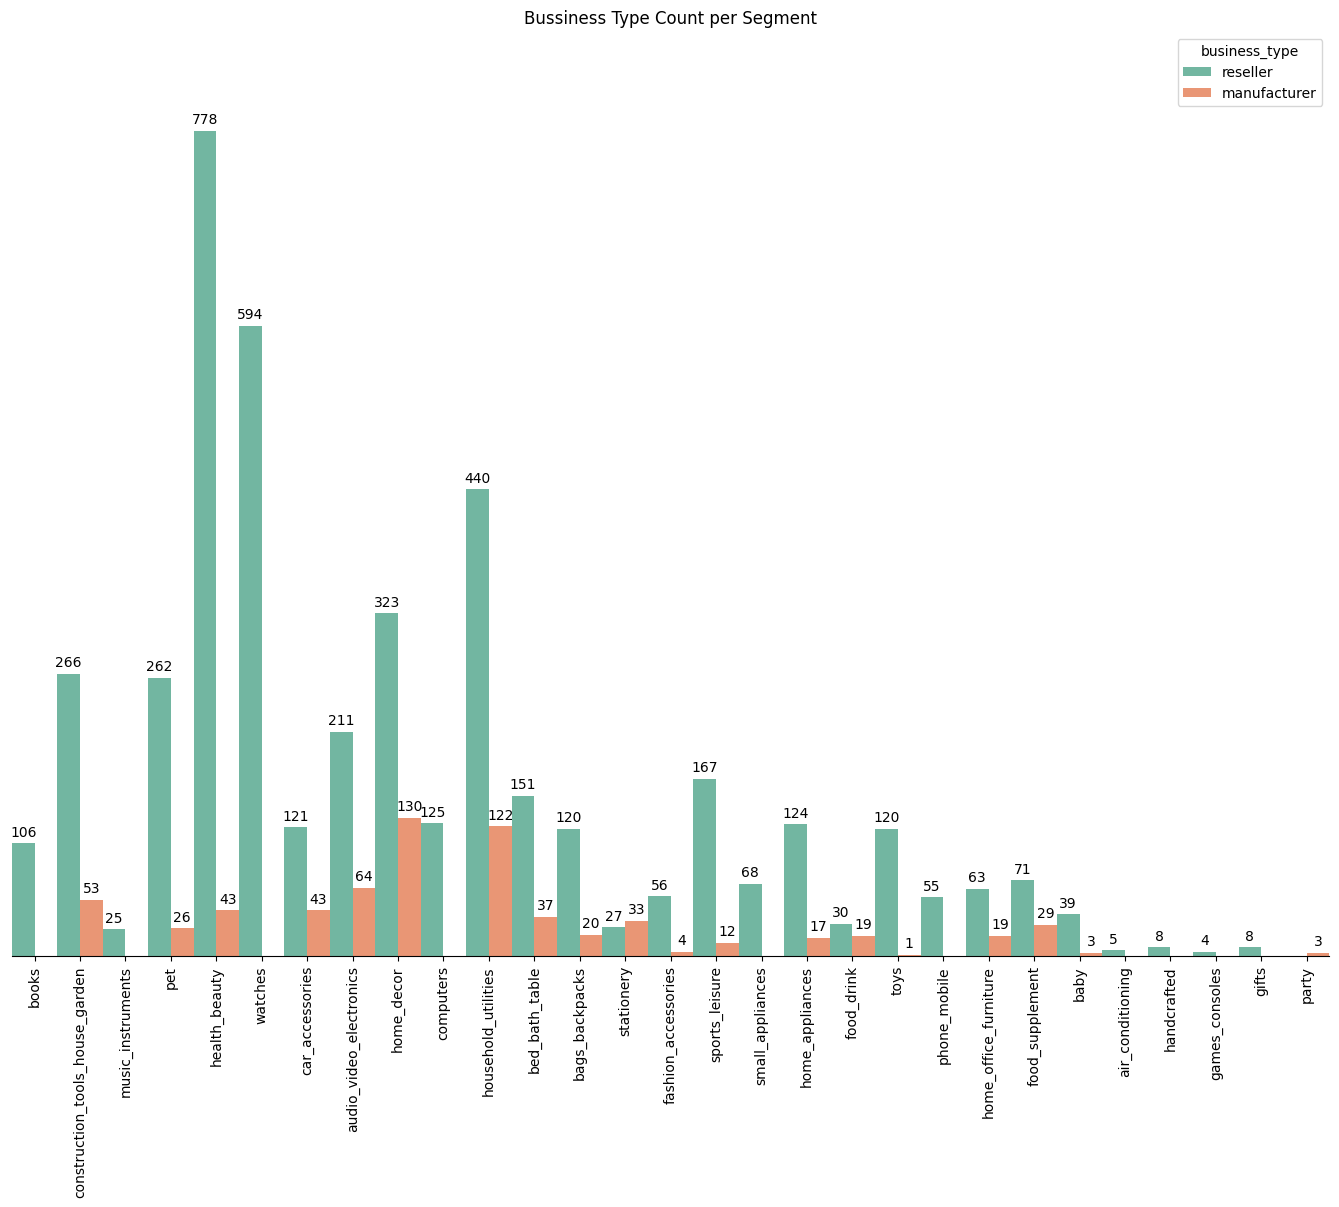

In [49]:
#How do sellers compare across business types?
plt.figure(figsize =(17,12))
chart = sns.countplot(data=df, x='business_segment', width = 1, hue='business_type', palette='Set2')
plt.xlabel('')
plt.title('Bussiness Type Count per Segment')
plt.xticks(rotation=90);
clean_chart(chart,labels=True,fmt='%.0f' , rota =0);

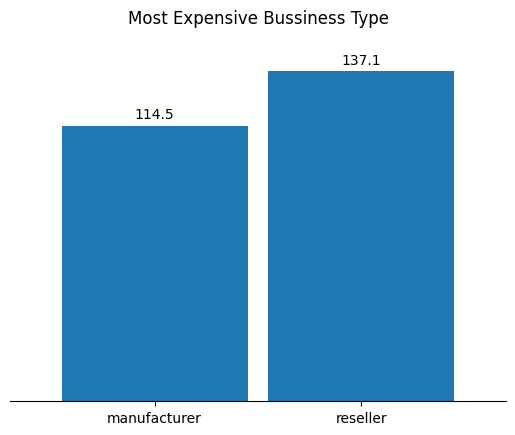

In [51]:
#Are resellers more expensive than manufacturers? yes
price_filter= df.groupby('business_type')['price'].mean()
chart = price_filter.plot(kind = 'bar', stacked=False, rot=0, width = 0.90, title='Most Expensive Bussiness Type', xlabel = '');
clean_chart(chart,labels=True,fmt='%.1f' , rota =0);

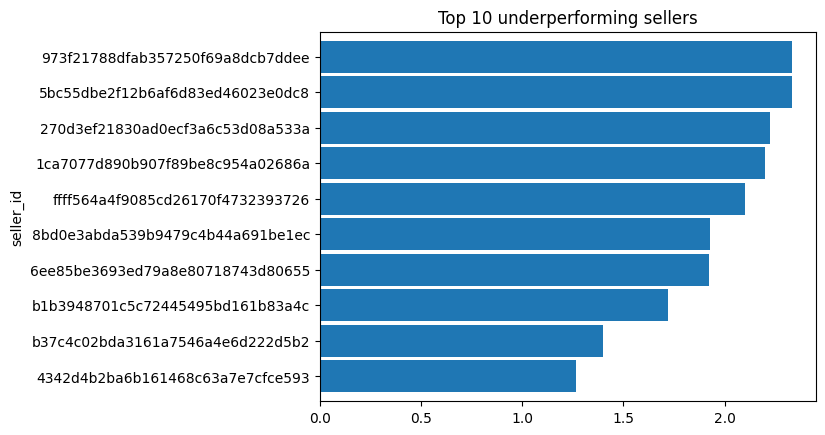

In [40]:
# Who are the red-flag (underperforming) sellers? FS
# avarage score and number of reviews per seller
seller_perform = df.groupby('seller_id')['review_score'].agg(['mean','count'])
# consider sellers with at least 10 review only, take the 10 lowest only 
Red_flags = seller_perform[seller_perform['count']>=10].nsmallest(10,'mean')
# plot the mean only
chart = Red_flags['mean'].plot(kind = 'barh', stacked=False, rot=0, width = 0.90, title='Top 10 underperforming sellers', xlabel = '');


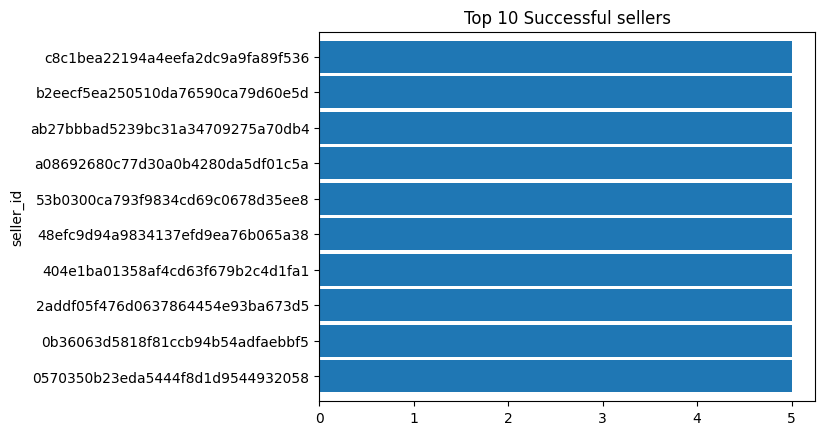

In [62]:
#Who are the most successful sellers? the opposit of above . FS
# avarage score and number of reviews per seller
seller_perform = df.groupby('seller_id')['review_score'].agg(['mean','count'])
# consider sellers with at least 10 review only, take the 10 lowest only 
green_flags = seller_perform[seller_perform['count']>=10].nlargest(10,'mean')
# plot the mean only
chart = green_flags['mean'].plot(kind = 'barh', stacked=False, rot=0, width = 0.90, title='Top 10 Successful sellers', xlabel = '');

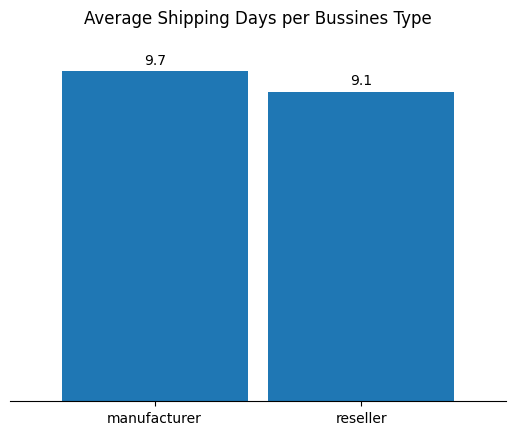

In [52]:
#Do manufacturers ship orders faster to carriers than resellers, and how does this affect seller ratings? FS
df['delivery_days'] = (df['order_delivered_customer_date']- df['order_purchase_timestamp']).dt.days
order_delivery= df.groupby('business_type')['delivery_days'].mean()
chart = order_delivery.plot(kind = 'bar', stacked=False, rot=0, width = 0.90, title='Average Shipping Days per Bussines Type', xlabel = '');
clean_chart(chart,labels=True,fmt='%.1f' , rota =0);

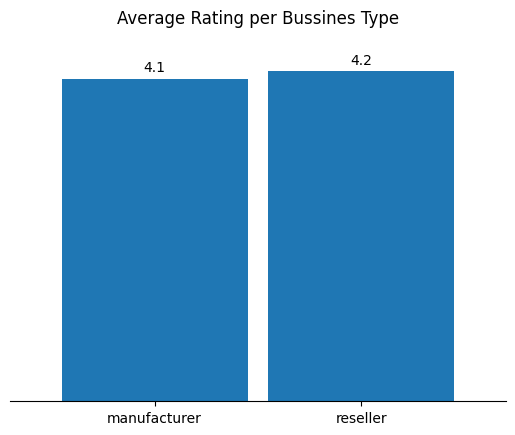

In [53]:
#and how does this affect seller ratings
seller_rating= df.groupby('business_type')['review_score'].mean()
chart = seller_rating.plot(kind = 'bar', stacked=False, rot=0, width = 0.90, title='Average Rating per Bussines Type', xlabel = '');
clean_chart(chart,labels=True,fmt='%.1f' , rota =0);